In [ ]:
import numpy as np

# Define the activation function
def step_function(x):
    return 1 if x >= 0 else 0

# Define the Perceptron model
class Perceptron:
    def __init__(self, input_size, learning_rate=0.1):
        self.weights = np.zeros(input_size + 1)
        self.learning_rate = learning_rate

    def predict(self, x):
        summation = np.dot(x, self.weights[1:]) + self.weights[0]
        return step_function(summation)

    def train(self, training_data, labels, epochs=10):
        for _ in range(epochs):
            for x, label in zip(training_data, labels):
                prediction = self.predict(x)
                self.weights[1:] += self.learning_rate * (label - prediction) * x
                self.weights[0] += self.learning_rate * (label - prediction)

# Define the training data for AND and OR gates
# AND gate
training_data_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
labels_and = np.array([0, 0, 0, 1])

# OR gate
training_data_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
labels_or = np.array([0, 1, 1, 1])

# Create Perceptron models
perceptron_and = Perceptron(input_size=2)
perceptron_or = Perceptron(input_size=2)

# Train the models
perceptron_and.train(training_data_and, labels_and, epochs=10)
perceptron_or.train(training_data_or, labels_or, epochs=10)

# Test the models
print("AND Gate")
for x in training_data_and:
    print(f"{x} => {perceptron_and.predict(x)}")

print("OR Gate")
for x in training_data_or:
    print(f"{x} => {perceptron_or.predict(x)}")


AND Gate
[0 0] => 0
[0 1] => 0
[1 0] => 0
[1 1] => 1
OR Gate
[0 0] => 0
[0 1] => 1
[1 0] => 1
[1 1] => 1


In [ ]:
import pandas as pd


file_path = '/content/horseRacing.csv'
df = pd.read_csv(file_path)


In [ ]:
df = df.drop_duplicates()


df = df.fillna(df.median())

In [ ]:
df['price_label'] = df['price'].apply(lambda x: 1 if 0 <= x <= 50 else 0)

print(df[['price', 'price_label']])


       price  price_label
0       17.0            1
1       26.0            1
2       17.0            1
3        4.0            1
4        7.0            1
...      ...          ...
98385   11.0            1
98386   81.0            0
98387    3.1            1
98388    7.0            1
98389   14.0            1

[98390 rows x 2 columns]


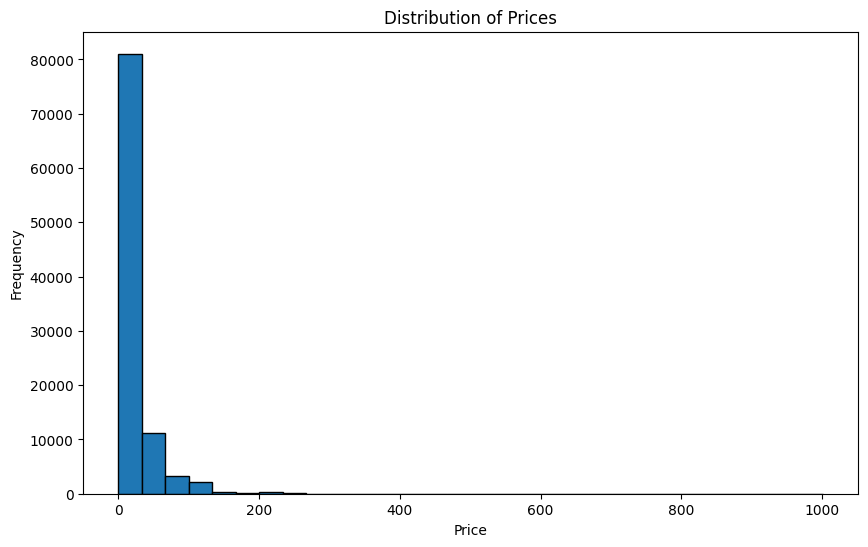

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of the 'price' column
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=30, edgecolor='k')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Prices')
plt.show()


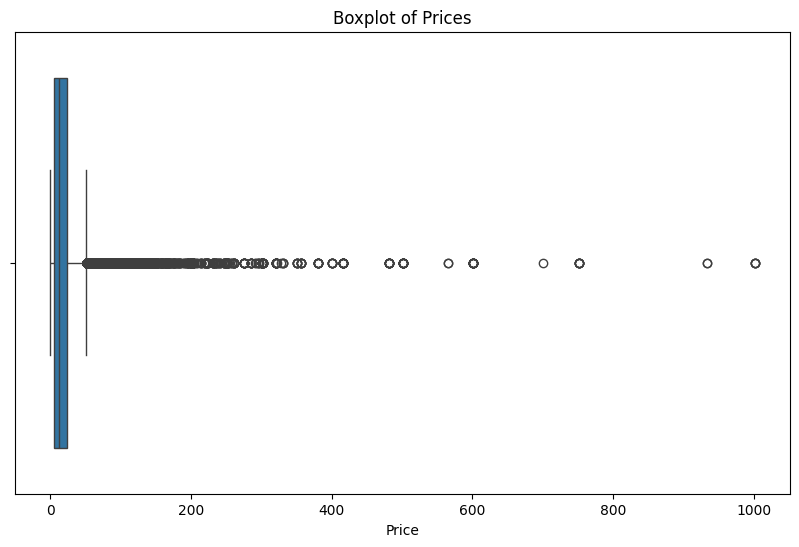

In [ ]:
# Boxplot of the 'price' column
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['price'])
plt.xlabel('Price')
plt.title('Boxplot of Prices')
plt.show()


In [ ]:

df_encoded = pd.get_dummies(df, columns=['race_id'])

print(df_encoded.head())


   horse_id  1-101  1-102  1-103  1-104  1-105  1-106  1-107  1-108  1-109  \
0    565129    NaN    NaN    NaN    NaN    NaN    NaN    NaN  -0.71   0.78   
1    607093    NaN    NaN    NaN    NaN    NaN    NaN    NaN  -0.05   0.78   
2    637337    NaN    NaN    NaN    NaN    NaN    NaN    NaN  -0.97   1.60   
3    659819    NaN    NaN    NaN    NaN    NaN    NaN    NaN   0.21  -0.88   
4    661530    NaN    NaN    NaN    NaN    NaN    NaN    NaN   0.08  -0.05   

   ...  race_id_691306  race_id_691329  race_id_691331  race_id_691338  \
0  ...           False           False           False           False   
1  ...           False           False           False           False   
2  ...           False           False           False           False   
3  ...           False           False           False           False   
4  ...           False           False           False           False   

   race_id_691538  race_id_691540  race_id_691872  race_id_691908  \
0           False

In [ ]:
df_encoded = pd.get_dummies(df, columns=['horse_id'])

print(df_encoded.head())

   race_id  1-101  1-102  1-103  1-104  1-105  1-106  1-107  1-108  1-109  \
0   495886    NaN    NaN    NaN    NaN    NaN    NaN    NaN  -0.71   0.78   
1   495886    NaN    NaN    NaN    NaN    NaN    NaN    NaN  -0.05   0.78   
2   495886    NaN    NaN    NaN    NaN    NaN    NaN    NaN  -0.97   1.60   
3   495886    NaN    NaN    NaN    NaN    NaN    NaN    NaN   0.21  -0.88   
4   495886    NaN    NaN    NaN    NaN    NaN    NaN    NaN   0.08  -0.05   

   ...  horse_id_1760069  horse_id_1765127  horse_id_1765129  \
0  ...             False             False             False   
1  ...             False             False             False   
2  ...             False             False             False   
3  ...             False             False             False   
4  ...             False             False             False   

   horse_id_1770387  horse_id_1770388  horse_id_1770390  horse_id_1770391  \
0             False             False             False             False  

In [ ]:
import numpy as np

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Initialize parameters
def initialize_parameters(input_size, hidden_size, output_size):
    params = {
        'W1': np.random.randn(input_size, hidden_size),
        'b1': np.zeros((1, hidden_size)),
        'W2': np.random.randn(hidden_size, output_size),
        'b2': np.zeros((1, output_size))
    }
    return params

# Forward propagation
def forward_propagation(X, params):
    Z1 = np.dot(X, params['W1']) + params['b1']
    A1 = sigmoid(Z1)
    Z2 = np.dot(A1, params['W2']) + params['b2']
    A2 = sigmoid(Z2)
    cache = {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2}
    return A2, cache

# Compute loss
def compute_loss(y_true, y_pred):
    m = y_true.shape[0]
    loss = -1/m * np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

# Backward propagation
def backward_propagation(X, y_true, params, cache):
    m = X.shape[0]
    dZ2 = cache['A2'] - y_true
    dW2 = 1/m * np.dot(cache['A1'].T, dZ2)
    db2 = 1/m * np.sum(dZ2, axis=0, keepdims=True)
    dZ1 = np.dot(dZ2, params['W2'].T) * sigmoid_derivative(cache['A1'])
    dW1 = 1/m * np.dot(X.T, dZ1)
    db1 = 1/m * np.sum(dZ1, axis=0, keepdims=True)

    grads = {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2}
    return grads

# Update parameters
def update_parameters(params, grads, learning_rate):
    params['W1'] -= learning_rate * grads['dW1']
    params['b1'] -= learning_rate * grads['db1']
    params['W2'] -= learning_rate * grads['dW2']
    params['b2'] -= learning_rate * grads['db2']
    return params

# Train the MLP
def train_mlp(X, y, input_size, hidden_size, output_size, epochs, learning_rate):
    params = initialize_parameters(input_size, hidden_size, output_size)
    for epoch in range(epochs):
        y_pred, cache = forward_propagation(X, params)
        loss = compute_loss(y, y_pred)
        grads = backward_propagation(X, y, params, cache)
        params = update_parameters(params, grads, learning_rate)
        if epoch % 100 == 0:
            print(f'Epoch {epoch}, Loss: {loss}')
    return params


if __name__ == "__main__":

    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y = np.array([[0], [1], [1], [0]])


    trained_params = train_mlp(X, y, input_size=2, hidden_size=2, output_size=1, epochs=1000, learning_rate=0.1)


    y_pred, _ = forward_propagation(X, trained_params)
    print('Predicted outputs:', y_pred)


Epoch 0, Loss: 0.7009269051529845
Epoch 100, Loss: 0.6934236307716433
Epoch 200, Loss: 0.6929608680451881
Epoch 300, Loss: 0.6925026780419552
Epoch 400, Loss: 0.6920153996144293
Epoch 500, Loss: 0.6914643077675374
Epoch 600, Loss: 0.6908089489595521
Epoch 700, Loss: 0.689999415739975
Epoch 800, Loss: 0.6889721555114855
Epoch 900, Loss: 0.6876454192691712
Predicted outputs: [[0.47522786]
 [0.52667376]
 [0.48699417]
 [0.52202226]]


In [ ]:
pip install scikit-learn


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
def evaluate_mlp(X, y_true, params):

    y_pred, _ = forward_propagation(X, params)


    y_pred_binary = (y_pred > 0.5).astype(int)


    cm = confusion_matrix(y_true, y_pred_binary)
    print("Confusion Matrix:")
    print(cm)


    print("\nClassification Report:")
    print(classification_report(y_true, y_pred_binary))


    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred)
    print("\nAUC: {:.2f}".format(auc))

    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, label="ROC Curve (AUC = {:.2f})".format(auc))
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='best')
    plt.show()

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()


Epoch 0, Loss: 0.6894328550444173
Epoch 100, Loss: 0.6844263948866157
Epoch 200, Loss: 0.6792390231368786
Epoch 300, Loss: 0.6733560089440661
Epoch 400, Loss: 0.6665279152194057
Epoch 500, Loss: 0.6585701946345481
Epoch 600, Loss: 0.649370813687228
Epoch 700, Loss: 0.6389032101801522
Epoch 800, Loss: 0.6272415427411399
Epoch 900, Loss: 0.6145672021107964
Confusion Matrix:
[[1 1]
 [0 2]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4


AUC: 0.75


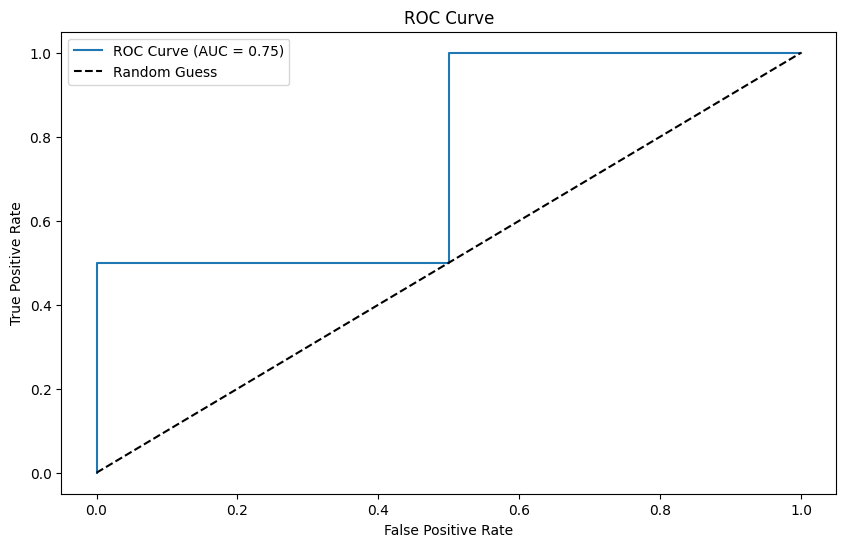

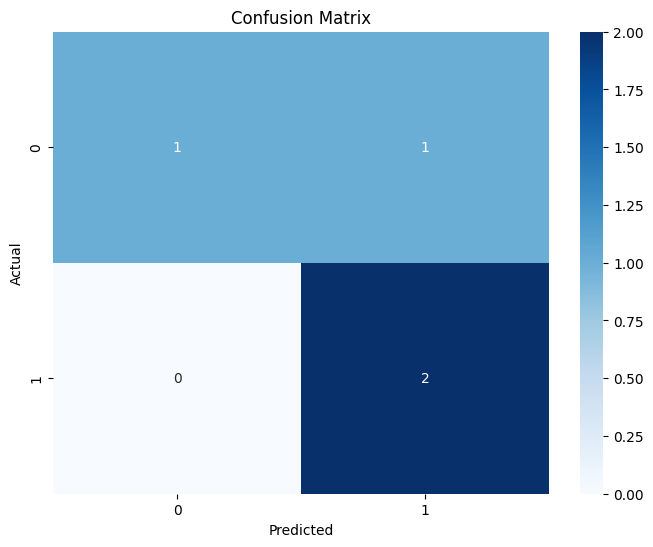

In [ ]:
if __name__ == "__main__":

    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y = np.array([[0], [1], [1], [0]])


    trained_params = train_mlp(X, y, input_size=2, hidden_size=2, output_size=1, epochs=1000, learning_rate=0.1)


    evaluate_mlp(X, y, trained_params)
